In [ ]:
pip install osmnx

In [ ]:
pip install folium matplotlib mapclassify

In [3]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import folium
import time
import copy
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

In [4]:
place_name = "Alto Selva Alegre, Arequipa, Perú"
G = ox.graph_from_place(place_name, network_type="walk")

In [ ]:
# Graficar el grafo y obtener los ejes
fig, ax = ox.plot_graph(
    G,
    node_size=4,
    node_color="blue",
    edge_color="green",         # Color de las aristas
    edge_linewidth=0.5,        # Ancho de las aristas
    bgcolor="white",
    show=False,  # No mostrar inmediatamente
    close=False  # No cerrar automáticamente
)

# Agregar un título al gráfico
ax.set_title("Pedestrian network map - Alto Selva Alegre, Arequipa, Peru", fontsize=16)

# Crear elementos para la leyenda
legend_elements = [
    Line2D([0], [0], color="blue", marker='o', markersize=5, linestyle="None", label="Nodes (intersections)"),
    Line2D([0], [0], color="green", linewidth=2, label="Edges (streets)")
]

# Agregar la leyenda al gráfico
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, frameon=True, facecolor="white")

# Mostrar el gráfico
plt.show()

In [ ]:
# Obtener el número de nodos en el grafo
num_nodos = G.number_of_nodes()
print(f"Cantidad de nodos en el grafo: {num_nodos}")

=============================================0

In [ ]:
pip install networkx python-louvain geopandas matplotlib pulp

In [1]:
import networkx as nx
import community as community_louvain
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, value
import random
import matplotlib.pyplot as plt

In [2]:
# --- 1. Construcción del grafo ---
G = nx.Graph()

# Añadimos nodos con probabilidades de rabia
for i in range(1, 21):
    G.add_node(i, prob_rabia=random.uniform(0, 1))  # Probabilidad aleatoria entre 0 y 1
    
print(G.nodes(data=True))

[(1, {'prob_rabia': 0.7914638995742062}), (2, {'prob_rabia': 0.8325876339057517}), (3, {'prob_rabia': 0.4422112735597298}), (4, {'prob_rabia': 0.26805438557788563}), (5, {'prob_rabia': 0.5487043430520846}), (6, {'prob_rabia': 0.9372581063357966}), (7, {'prob_rabia': 0.3114462260424631}), (8, {'prob_rabia': 0.7065590709642076}), (9, {'prob_rabia': 0.2631564300197107}), (10, {'prob_rabia': 0.9030933532023784}), (11, {'prob_rabia': 0.16256464189245334}), (12, {'prob_rabia': 0.25988350909173186}), (13, {'prob_rabia': 0.16160545796604564}), (14, {'prob_rabia': 0.9455373879835227}), (15, {'prob_rabia': 0.12945802713252752}), (16, {'prob_rabia': 0.38348986897767356}), (17, {'prob_rabia': 0.9376972636228992}), (18, {'prob_rabia': 0.5995620671992496}), (19, {'prob_rabia': 0.05696589488874837}), (20, {'prob_rabia': 0.2774666209730765})]


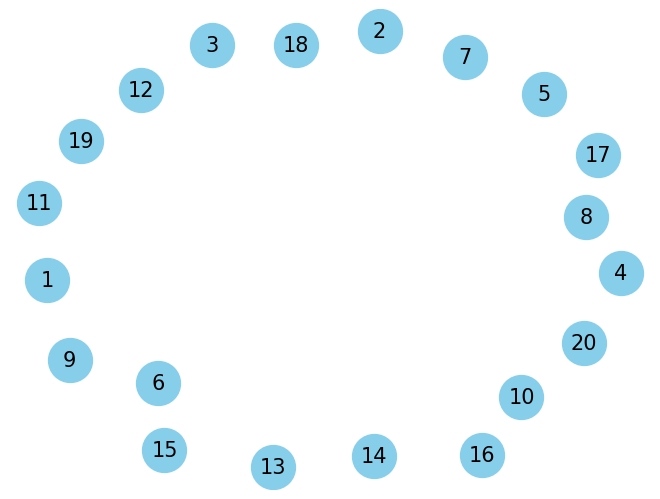

In [3]:
# Dibujar el grafo
nx.draw(G, with_labels=True, node_color="skyblue", node_size=1000, font_size=15, font_color="black", edge_color="gray")

# Mostrar la visualización
plt.show()

In [4]:
# Añadimos aristas (distancias caminadas)
edges = [
    (1, 2, 0.5), (2, 3, 1.0), (3, 4, 1.5), (4, 5, 2.0),
    (5, 6, 1.0), (6, 7, 0.8), (7, 8, 0.9), (8, 9, 1.2),
    (9, 10, 1.5), (10, 11, 1.0), (11, 12, 1.8), (12, 13, 1.2),
    (13, 14, 1.6), (14, 15, 2.0), (15, 16, 0.7), (16, 17, 1.3),
    (17, 18, 1.1), (18, 19, 1.7), (19, 20, 2.1), (20, 1, 2.0)
]
for u, v, weight in edges:
    G.add_edge(u, v, weight=weight)

print(G.edges(data=True))

[(1, 2, {'weight': 0.5}), (1, 20, {'weight': 2.0}), (2, 3, {'weight': 1.0}), (3, 4, {'weight': 1.5}), (4, 5, {'weight': 2.0}), (5, 6, {'weight': 1.0}), (6, 7, {'weight': 0.8}), (7, 8, {'weight': 0.9}), (8, 9, {'weight': 1.2}), (9, 10, {'weight': 1.5}), (10, 11, {'weight': 1.0}), (11, 12, {'weight': 1.8}), (12, 13, {'weight': 1.2}), (13, 14, {'weight': 1.6}), (14, 15, {'weight': 2.0}), (15, 16, {'weight': 0.7}), (16, 17, {'weight': 1.3}), (17, 18, {'weight': 1.1}), (18, 19, {'weight': 1.7}), (19, 20, {'weight': 2.1})]


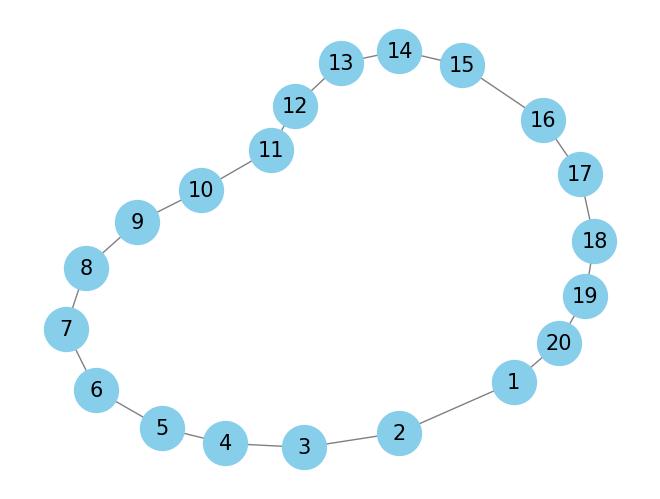

In [5]:
# Dibujar el grafo
nx.draw(G, with_labels=True, node_color="skyblue", node_size=1000, font_size=15, font_color="black", edge_color="gray")

# Mostrar la visualización
plt.show()

In [7]:
# --- 2. Detección de comunidades ---
partition = community_louvain.best_partition(G, weight='weight')
nx.set_node_attributes(G, partition, 'comunidad')

print(G.nodes(data=True))

[(1, {'prob_rabia': 0.7914638995742062, 'comunidad': 0}), (2, {'prob_rabia': 0.8325876339057517, 'comunidad': 1}), (3, {'prob_rabia': 0.4422112735597298, 'comunidad': 1}), (4, {'prob_rabia': 0.26805438557788563, 'comunidad': 1}), (5, {'prob_rabia': 0.5487043430520846, 'comunidad': 1}), (6, {'prob_rabia': 0.9372581063357966, 'comunidad': 2}), (7, {'prob_rabia': 0.3114462260424631, 'comunidad': 2}), (8, {'prob_rabia': 0.7065590709642076, 'comunidad': 2}), (9, {'prob_rabia': 0.2631564300197107, 'comunidad': 2}), (10, {'prob_rabia': 0.9030933532023784, 'comunidad': 2}), (11, {'prob_rabia': 0.16256464189245334, 'comunidad': 3}), (12, {'prob_rabia': 0.25988350909173186, 'comunidad': 3}), (13, {'prob_rabia': 0.16160545796604564, 'comunidad': 3}), (14, {'prob_rabia': 0.9455373879835227, 'comunidad': 3}), (15, {'prob_rabia': 0.12945802713252752, 'comunidad': 3}), (16, {'prob_rabia': 0.38348986897767356, 'comunidad': 0}), (17, {'prob_rabia': 0.9376972636228992, 'comunidad': 0}), (18, {'prob_rabi

4


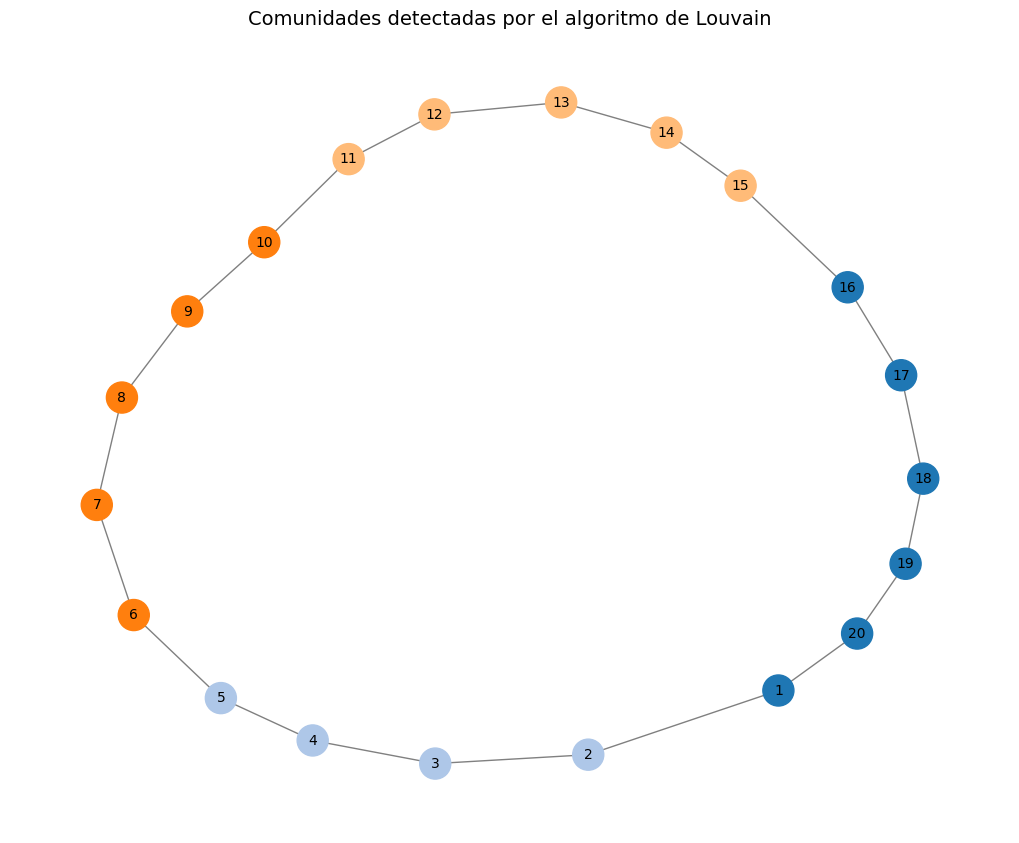

In [8]:
# Crear una lista de colores para cada nodo según su comunidad
# Cada comunidad será asignada a un número en `partition`
num_comunidades = max(partition.values()) + 1  # Total de comunidades
print(num_comunidades)
colores = plt.cm.tab20(range(num_comunidades))  # Elegir una paleta con colores suficientes
node_colors = [colores[partition[node]] for node in G.nodes()]

# --- 3. Dibujar el grafo ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Disposición de los nodos (puedes usar otro layout)
nx.draw(
    G, pos, 
    node_color=node_colors, 
    with_labels=True, 
    node_size=500, 
    font_size=10, 
    edge_color="gray"
)
plt.title("Comunidades detectadas por el algoritmo de Louvain", fontsize=14)
plt.show()

In [9]:
# --- 3. Optimización ---
max_distance = 2.0
high_risk_nodes = [n for n, data in G.nodes(data=True) if data['prob_rabia'] > 0.8]

high_risk_nodes

[2, 6, 10, 14, 17]

In [19]:
# Crear modelo
model = LpProblem("Optimización_de_Puntos_de_Vacunación", LpMinimize)

# Variables de decisión
x = LpVariable.dicts("Vacunación", G.nodes, cat="Binary")
z = LpVariable.dicts("No_Cubierto", high_risk_nodes, cat="Binary")  # Nodos no cubiertos

# --- 4. Optimización basada en comunidades ---
# Agrupar los nodos de alto riesgo por comunidad
communities = {}
for node in high_risk_nodes:
    comunidad = G.nodes[node]['comunidad']
    if comunidad not in communities:
        communities[comunidad] = []
    communities[comunidad].append(node)

# Para cada comunidad, asegurar que esté cubierta
for comunidad, nodes_in_com in communities.items():
    for node in nodes_in_com:
        # Definir la cobertura de cada nodo en esta comunidad
        cobertura = [n for n in G.nodes if nx.has_path(G, n, node) and nx.shortest_path_length(G, n, node, weight='weight') <= max_distance]
        model += lpSum(x[n] for n in cobertura) + z[node] >= 1  # Cada nodo debe estar cubierto

# Función objetivo: Minimizar puntos de vacunación, penalizar nodos no cubiertos, y optimizar cobertura por comunidad
model += (
    lpSum(x[n] for n in G.nodes)  # Minimizar puntos de vacunación
    - lpSum(
        G.nodes[node]['prob_rabia'] * lpSum(
            x[n] for n in G.nodes if nx.has_path(G, n, node) and nx.shortest_path_length(G, n, node, weight='weight') <= max_distance
        ) for node in high_risk_nodes
    )  # Maximizar cobertura ponderada
    + lpSum(10 * z[node] for node in high_risk_nodes)  # Penalizar nodos no cubiertos
)

# Resolver modelo
model.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/pantro/Documentos/GITHUB/doutoradoCS/myenv/lib/python3.12/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/2bcd7bb27dea4a6c8181bf292dbe7334-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/2bcd7bb27dea4a6c8181bf292dbe7334-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 10 COLUMNS
At line 108 RHS
At line 114 BOUNDS
At line 140 ENDATA
Problem MODEL has 5 rows, 25 columns and 22 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -0.556174 - 0.00 seconds
Cgl0004I processed model has 3 rows, 6 columns (6 integer (3 of which binary)) and 6 elements
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I Solution found of -0.556174
Cbc0038I Cleaned solution of -0.556174
Cbc0038I Before mini branch and bound, 6 integers at bound fixed and 0 continuous of which 3 

1

In [20]:
# --- 5. Resultados ---
selected_vaccination_points = [n for n in G.nodes if value(x[n]) == 1]
not_covered_nodes = [node for node in high_risk_nodes if value(z[node]) == 1]

print("Puntos de vacunación seleccionados:", selected_vaccination_points)
print("Nodos de alto riesgo no cubiertos:", not_covered_nodes)
print("Porcentaje de cobertura:", (len(high_risk_nodes) - len(not_covered_nodes)) / len(high_risk_nodes) * 100, "%")

Puntos de vacunación seleccionados: [1, 8, 11, 15]
Nodos de alto riesgo no cubiertos: []
Porcentaje de cobertura: 100.0 %


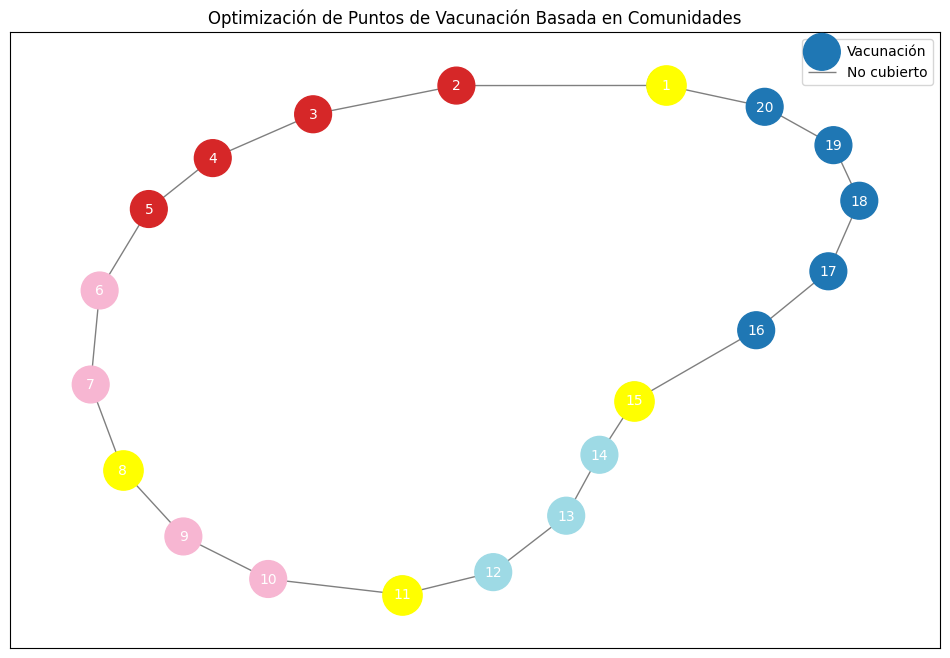

In [21]:
# --- 6. Visualización ---
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 8))

# Colores por comunidad
comunidades = [partition[n] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=700, cmap=plt.cm.tab20, node_color=comunidades)
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")

# Resaltamos puntos de vacunación
nx.draw_networkx_nodes(G, pos, nodelist=selected_vaccination_points, node_size=800, node_color="yellow", label="Vacunación")

# Resaltamos nodos no cubiertos
nx.draw_networkx_nodes(G, pos, nodelist=not_covered_nodes, node_size=800, node_color="orange", label="No cubierto")

plt.title("Optimización de Puntos de Vacunación Basada en Comunidades")
plt.legend(["Vacunación", "No cubierto"])
plt.show()